First 5 rows:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


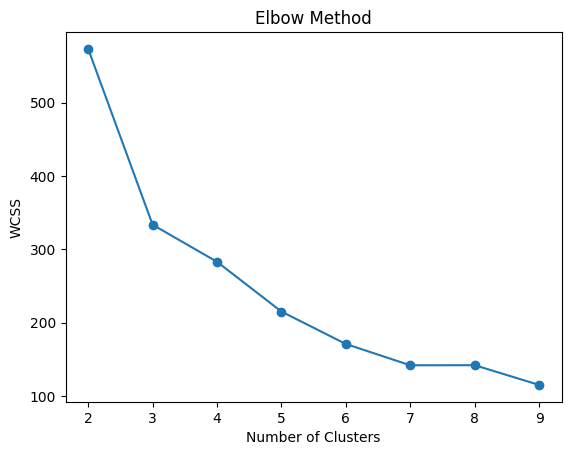

K-Means Silhouette Score: 0.43537421146600425
Hierarchical Silhouette Score: 0.39074082595174053


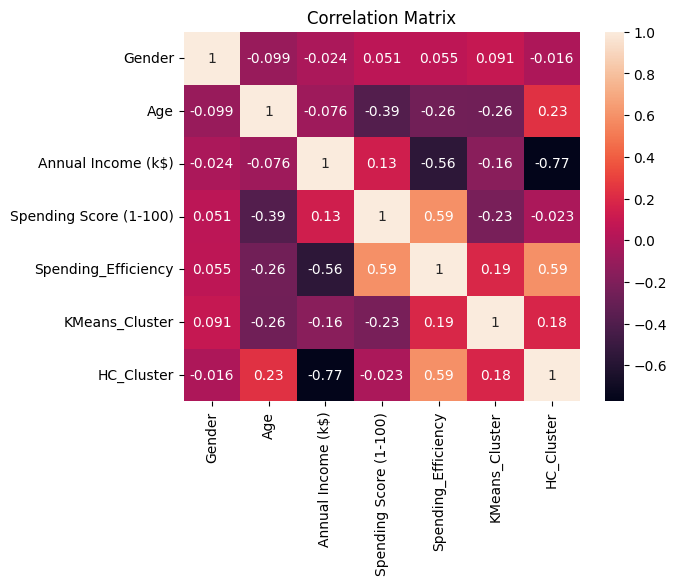

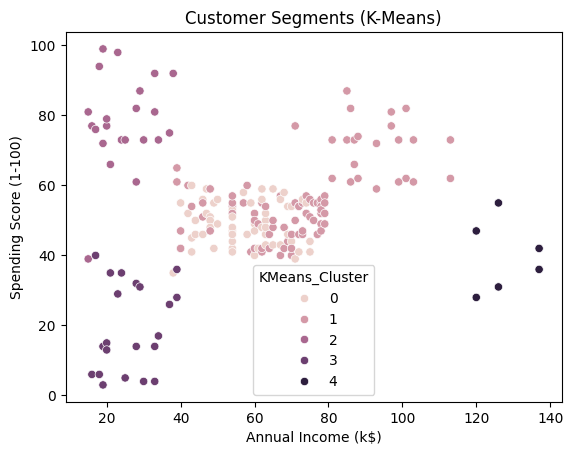

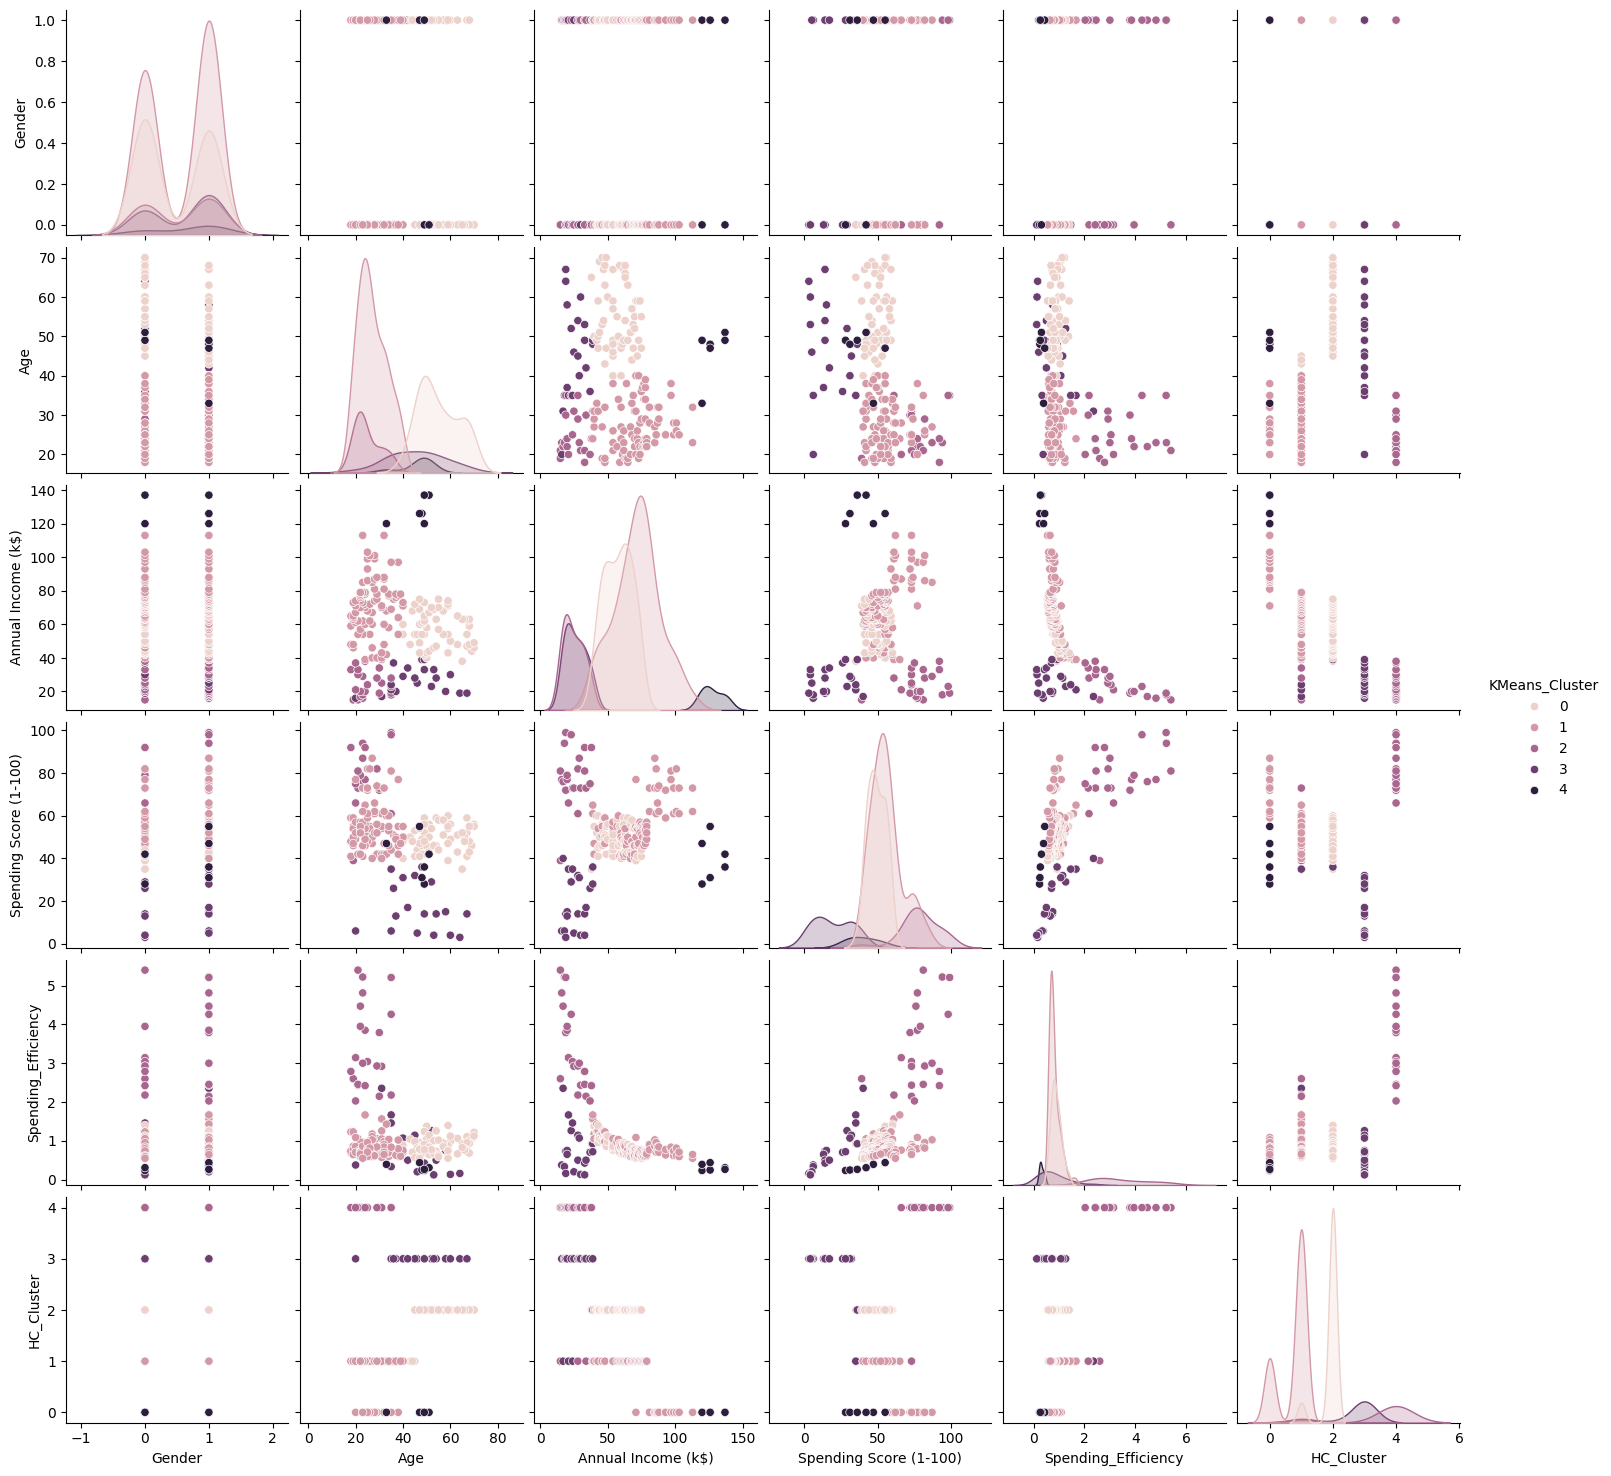


Cluster Summary:
                  Gender        Age  Annual Income (k$)  \
KMeans_Cluster                                            
0               0.474576  54.932203           57.677966   
1               0.565217  27.065217           71.956522   
2               0.545455  25.045455           24.636364   
3               0.619048  45.523810           26.285714   
4               0.666667  46.166667          127.666667   

                Spending Score (1-100)  Spending_Efficiency  HC_Cluster  
KMeans_Cluster                                                           
0                            49.050847             0.878833    1.915254  
1                            55.782609             0.808610    0.750000  
2                            78.181818             3.411306    3.590909  
3                            19.380952             0.770296    2.666667  
4                            39.833333             0.312814    0.000000  

Gender Distribution:
Gender           0   1
KMean

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

df = pd.read_csv("Mall_Customers.csv")

print("First 5 rows:")
print(df.head())

#  DATA PREPROCESSING
# Drop CustomerID
df = df.drop('CustomerID', axis=1)

# Encode Gender
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

#FEATURE ENGINEERING
# Spending Efficiency
df['Spending_Efficiency'] = df['Spending Score (1-100)'] / df['Annual Income (k$)']

# Age Groups
df['Age_Group'] = pd.cut(df['Age'], 
                        bins=[18,25,35,50,70], 
                        labels=['Young','Adult','Mid','Senior'])


# FEATURE SELECTION
features = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Spending_Efficiency']]

#FEATURE SCALING
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

# ELBOW METHOD (K-MEANS)
wcss = []
for i in range(2, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.figure()
plt.plot(range(2,10), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

# APPLY K-MEANS
kmeans = KMeans(n_clusters=5, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(scaled_data)

#HIERARCHICAL CLUSTERING

hc = AgglomerativeClustering(n_clusters=5)
df['HC_Cluster'] = hc.fit_predict(scaled_data)


#SILHOUETTE SCORE

kmeans_score = silhouette_score(scaled_data, df['KMeans_Cluster'])
hc_score = silhouette_score(scaled_data, df['HC_Cluster'])

print("K-Means Silhouette Score:", kmeans_score)
print("Hierarchical Silhouette Score:", hc_score)

# CORRELATION HEATMAP

plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()


#CLUSTER VISUALIZATION

plt.figure()
sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['KMeans_Cluster']
)
plt.title("Customer Segments (K-Means)")
plt.show()


# PAIRPLOT (ADVANCED VISUAL)
sns.pairplot(df, hue='KMeans_Cluster')
plt.show()

# CLUSTER INSIGHTS

cluster_summary = df.groupby('KMeans_Cluster').mean(numeric_only=True)
print("\nCluster Summary:")
print(cluster_summary)

# GENDER DISTRIBUTION
print("\nGender Distribution:")
print(pd.crosstab(df['KMeans_Cluster'], df['Gender']))


# STRATEGY RECOMMENDATION SYSTEM
def recommend_strategy(cluster):
    if cluster == 0:
        return "Low Priority - Minimal Marketing"
    elif cluster == 1:
        return "Target with Discounts & Offers"
    elif cluster == 2:
        return "High Spenders - Premium Targeting"
    elif cluster == 3:
        return "Upsell Products & Cross-Sell"
    else:
        return "Engagement Campaigns"

df['Marketing_Strategy'] = df['KMeans_Cluster'].apply(recommend_strategy)

# SAVE FINAL OUTPUT
df.to_csv("segmented_customers.csv", index=False)

print("\nFinal dataset saved as segmented_customers.csv")


#SAMPLE OUTPUT

print("\nSample Data with Clusters & Strategy:")
print(df.head())